In [178]:
import numpy as np
import matplotlib.pyplot as plt

In [179]:
# Defining loss function, MSE (observed - predicted)^2 / n

# Firstly, we have to find what we predict for each sample.

def loss(x,y,w,b):

  ss = 0

  for i in range(len(x)):

    ss += pow((y[i] - (w * x[i] + b)), 2)


  return ss / len(x)


In [180]:
def step(x,y,w,b, learning_rate):

  grad_w = 0
  grad_b = 0

  step_size_w, step_size_b = 0,0

  for i in range(len(x)):

    grad_w +=  2 * (y[i] - (w * x[i] + b)) * (-x[i])
    grad_b +=  2 * (y[i] - (w * x[i] + b)) * (-1)

  step_size_w = grad_w / len(x) * learning_rate
  step_size_b = grad_b / len(x) * learning_rate

  w -= step_size_w
  b -= step_size_b

  return w, b

In [181]:
def fit(x, y, learning_rate=0.045, max_step=1000):

  w = 1 # Random values for parameters
  b = 0

  n_iter = 0
  losses = []
  w_hist = []
  b_hist = []

  while(n_iter < max_step):
    w_hist.append(w)
    b_hist.append(b)

    w, b = step(x,y,w,b, learning_rate)

    curr_loss = loss(x,y,w,b)

    losses.append(curr_loss)


    n_iter += 1

  return w, b, losses, w_hist, b_hist


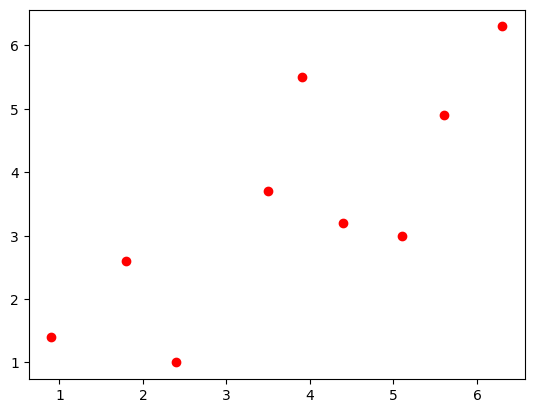

In [182]:
# X = weights of the mices
# Y = sizes of the mices

y = np.array([1.4, 2.6, 1.0, 3.7, 5.5, 3.2, 3.0, 4.9, 6.3])
x = np.array([0.9, 1.8, 2.4, 3.5, 3.9, 4.4, 5.1, 5.6, 6.3])

plt.scatter(x,y, color='red')
plt.show()

lr: 0.001, w: 0.8747511498925697, b: 0.14602264700567505
lr: 0.01, w: 0.7831131026439737, b: 0.5575524542955985
lr: 0.045, w: 0.7778205727447588, b: 0.5813202437116205
lr: 0.055, w: 0.7778205150801288, b: 0.5813205026730367


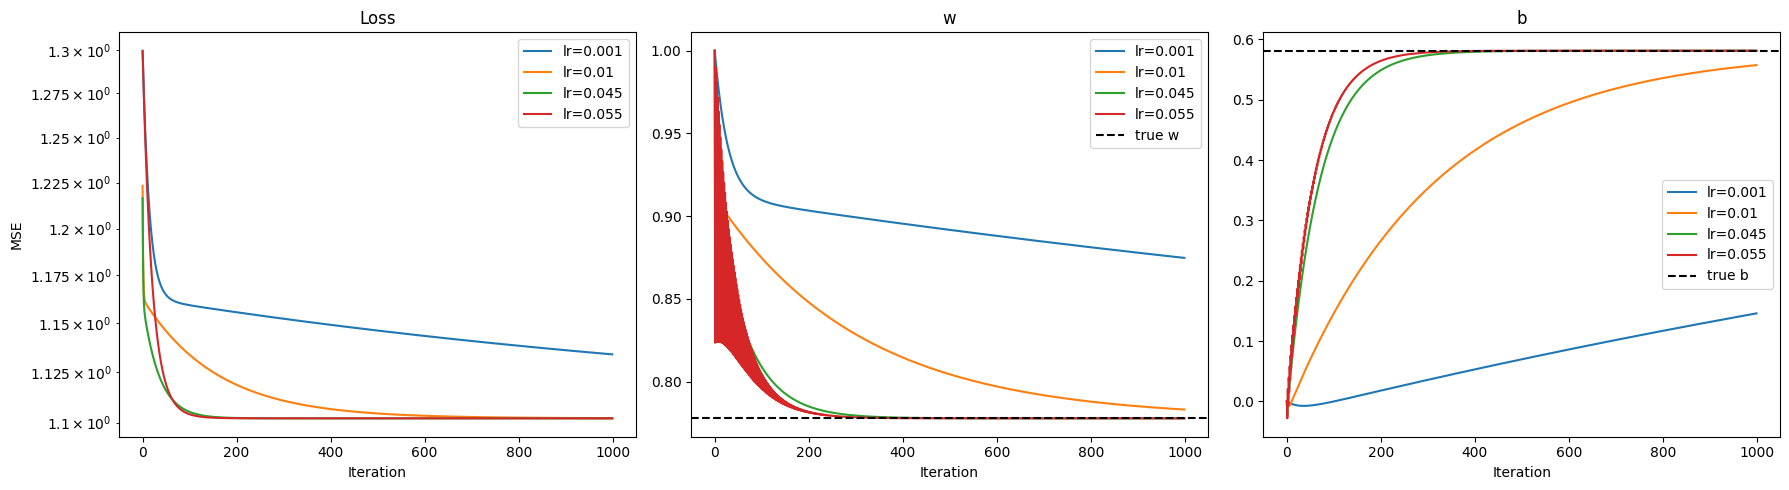

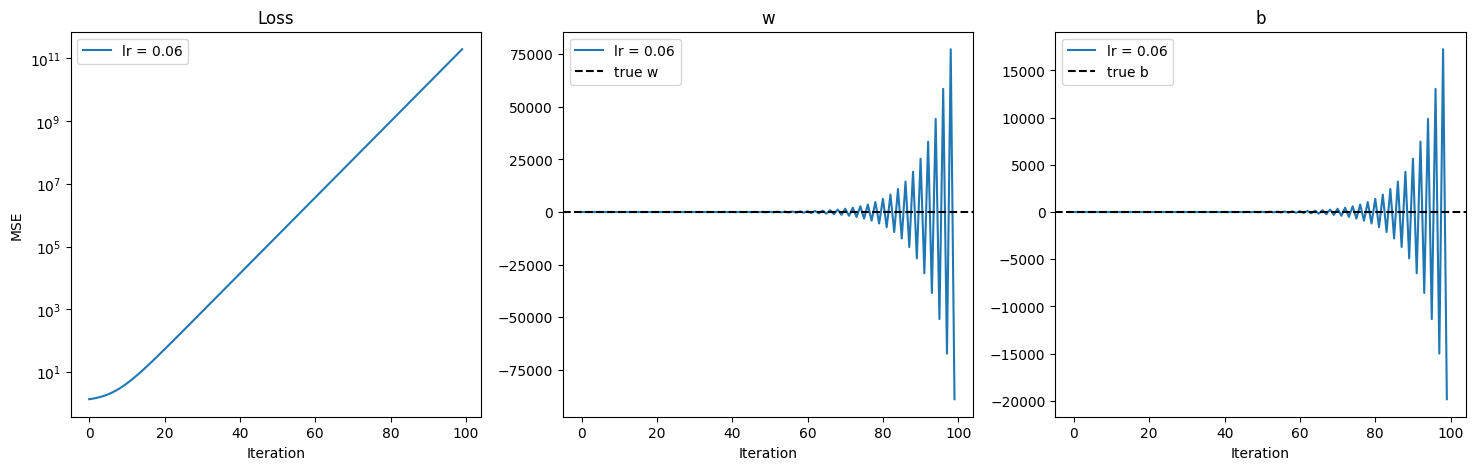

In [186]:
fig, axes = plt.subplots(1,3, figsize = (18,5))

for lr in [0.001, 0.01, 0.045, 0.055]:
  w, b, losses, w_hist, b_hist = fit(x,y, learning_rate=lr)
  axes[0].plot(losses, label=f"lr={lr}")
  axes[1].plot(w_hist, label=f"lr={lr}")
  axes[2].plot(b_hist, label=f"lr={lr}")
  print(f"lr: {lr}, w: {w}, b: {b}")

axes[0].set_title('Loss')
axes[0].set_yscale('log')
axes[0].set_ylabel('MSE')

axes[1].axhline(0.7778, color='black', linestyle='dashed', label='true w')
axes[1].set_title('w')

axes[2].axhline(0.5813, color='black', linestyle='dashed', label='true b')
axes[2].set_title('b')

for ax in axes:
    ax.set_xlabel('Iteration')
    ax.legend()

plt.tight_layout()
plt.show()


# Experiment for the lr = 0.06

lr = 0.06
fig, axes = plt.subplots(1,3, figsize = (18,5))
w, b, losses, w_hist, b_hist = fit(x,y, learning_rate=lr, max_step=100)
axes[0].plot(losses, label = f"lr = {lr}")
axes[1].plot(w_hist, label = f"lr = {lr}")
axes[2].plot(b_hist, label = f"lr = {lr}")

axes[0].set_title('Loss')
axes[0].set_yscale('log')
axes[0].set_ylabel('MSE')

axes[1].axhline(0.7778, color='black', linestyle='dashed', label='true w')
axes[1].set_title('w')

axes[2].axhline(0.5813, color='black', linestyle='dashed', label='true b')
axes[2].set_title('b')

for ax in axes:
    ax.set_xlabel('Iteration')
    ax.legend()

plt.xlabel('Iteration')
plt.show()